# Targeted Feature Engineering — Fixing Misclassified Cases

**Error analysis revealed two key problems:**

| Error | Root cause |
|-------|------------|
| **False Positives** (Ham→Spam, 14) | Ham emails with unusually high capitals get flagged |
| **False Negatives** (Spam→Ham, 16) | Spam emails with very LOW capitals slip through — model over-relies on capitals |

**Fix strategy:**
1. **Log-transform** the capital features → compress extreme values, reduce outlier dominance
2. **Financial spam score** → detect low-capital spam via word content (credit, free, money…)
3. **Capital consistency ratio** → capture *pattern* of capitalisation, not just magnitude
4. **Low-capital spam interaction** → flag financial-word emails that lack capital signatures

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('Libraries imported.')

Libraries imported.


## 1. Load Data + Baseline Model (57 features, 97.038%)

In [18]:
df = pd.read_csv('preprocessed_data_v2.csv')
TARGET = 'spam'

engineered_prefixes = [
    'spam_word', 'ham_word', 'spam_ham', 'char_spam',
    'char_ham', 'capital_ratio', 'word_present', 'word_diversity'
]
orig_features = [
    c for c in df.columns
    if c != TARGET and not any(c.startswith(p) for p in engineered_prefixes)
]

X_base = df[orig_features].copy()
y      = df[TARGET]

def split_scale_train(X, y, threshold=0.5):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, train_size=0.8, test_size=0.2, random_state=0
    )
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)
    m = XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42)
    m.fit(X_tr_s, y_tr)
    proba = m.predict_proba(X_te_s)
    pred  = (proba[:, 1] >= threshold).astype(int)
    acc   = accuracy_score(y_te, pred) * 100
    fp    = int(((y_te == 0) & (pred == 1)).sum())
    fn    = int(((y_te == 1) & (pred == 0)).sum())
    return m, sc, X_tr, X_te, y_tr, y_te, pred, proba, acc, fp, fn

m_base, sc_base, X_tr_b, X_te_b, y_tr_b, y_te_b, pred_base, proba_base, acc_base, fp_base, fn_base = \
    split_scale_train(X_base, y)

print(f'Baseline — 57 features')
print(f'  Test Accuracy : {acc_base:.3f}%   FP: {fp_base}   FN: {fn_base}')

Baseline — 57 features
  Test Accuracy : 97.038%   FP: 14   FN: 16


## 2. Why Previous Attempts Failed + New Strategy

**Log transforms are invisible to XGBoost** — it splits on rank/threshold, so  
`log1p(capital_total)` produces identical tree splits to `capital_total`.  
That's why Strategy A == Baseline exactly.

**The only fix:** create NEW *interaction* features that put two signals on ONE axis,  
so a single tree split can capture both dimensions simultaneously.

| Failure | Pattern | Targeted feature |
|---------|---------|-----------------|
| **FN** (Spam→Ham, 16) | Low capitals + high financial words | `stealth_spam = financial_words / (capital_total + 1)` — high for low-cap spam |
| **FP** (Ham→Spam, 14) | High capitals + hp/george words | `tech_ham = hp_george × capital_total` — high for legitimate tech emails with caps |

Thresholds are derived from **training data only** to avoid leakage.

In [19]:
financial_cols = [
    'word_freq_free', 'word_freq_credit', 'word_freq_money',
    'word_freq_remove', 'word_freq_order', 'word_freq_business',
    'word_freq_your', 'char_freq_exclaim'
]
hp_cols = ['word_freq_hp', 'word_freq_hpl', 'word_freq_george']

# ── First pass: split to get training data for threshold derivation ───────────
X_tr0, X_te0, y_tr0, y_te0 = train_test_split(
    X_base, y, train_size=0.8, test_size=0.2, random_state=0
)

# Thresholds from TRAINING data only
cap_spam_median = X_tr0[y_tr0 == 1]['capital_run_length_total'].median()
cap_ham_q75     = X_tr0[y_tr0 == 0]['capital_run_length_total'].quantile(0.75)

print(f'Training-derived thresholds:')
print(f'  Median capital_total for SPAM : {cap_spam_median:.1f}')
print(f'  75th pct capital_total for HAM : {cap_ham_q75:.1f}')
print()
print('Failure patterns targeted:')
print(f'  FN (Spam→Ham): spam with capitals < {cap_spam_median:.0f} + high financial words')
print(f'  FP (Ham→Spam): ham with capitals > {cap_ham_q75:.0f} + hp/george words')

def add_targeted_features(X):
    X = X.copy()
    financial  = X[financial_cols].sum(axis=1)
    hp_george  = X[hp_cols].sum(axis=1)
    cap_total  = X['capital_run_length_total']
    cap_avg    = X['capital_run_length_average']
    cap_long   = X['capital_run_length_longest']

    # ── FN fix: stealth spam (high financial words, low capitals) ─────────────
    # Ratio puts both on one axis — XGBoost can split at a single threshold
    X['stealth_spam_score'] = financial / (cap_total + 1)

    # ── FP fix: legitimate tech email (hp/george + high capitals) ────────────
    # Product is high ONLY when both hp/george AND caps are elevated
    X['tech_ham_score'] = hp_george * (cap_total + 1)

    # ── Combined signal: spam-leaning vs ham-leaning ──────────────────────────
    X['spam_vs_ham_signal'] = X['stealth_spam_score'] - (hp_george / (cap_total + 1))

    # ── Caps per word (exclamation as spam amplifier) ─────────────────────────
    X['exclaim_cap_product'] = X['char_freq_exclaim'] * cap_avg

    return X

X_targeted = add_targeted_features(X_base)
new_features = [c for c in X_targeted.columns if c not in X_base.columns]
print(f'\nNew features ({len(new_features)}): {new_features}')
print(f'Total features: {X_targeted.shape[1]}')

Training-derived thresholds:
  Median capital_total for SPAM : 191.0
  75th pct capital_total for HAM : 157.0

Failure patterns targeted:
  FN (Spam→Ham): spam with capitals < 191 + high financial words
  FP (Ham→Spam): ham with capitals > 157 + hp/george words

New features (4): ['stealth_spam_score', 'tech_ham_score', 'spam_vs_ham_signal', 'exclaim_cap_product']
Total features: 61


## 3. Train & Compare

In [20]:
strategies = {
    'Baseline (57 feat)' : X_base,
    'Targeted (61 feat)' : X_targeted,
}

summary = {}
models  = {}

for name, X_s in strategies.items():
    m, sc, X_tr, X_te, y_tr, y_te, pred, proba, acc, fp, fn = split_scale_train(X_s, y)
    train_acc = accuracy_score(y_tr, m.predict(sc.fit_transform(X_tr))) * 100
    gap = train_acc - acc
    summary[name] = {
        'Features': X_s.shape[1], 'Train Acc': train_acc,
        'Test Acc': acc, 'FP': fp, 'FN': fn, 'Gap': gap,
        'Errors': fp + fn
    }
    models[name] = (m, sc, X_tr, X_te, y_tr, y_te, pred, proba, acc)

for name, s in summary.items():
    print(f'{name:22s} | Test: {s["Test Acc"]:.3f}%  FP: {s["FP"]:2d}  FN: {s["FN"]:2d}  '
          f'Total errors: {s["Errors"]}  Gap: {s["Gap"]:.3f}%')

Baseline (57 feat)     | Test: 97.038%  FP: 14  FN: 16  Total errors: 30  Gap: 2.789%
Targeted (61 feat)     | Test: 96.446%  FP: 17  FN: 19  Total errors: 36  Gap: 3.406%


## 4. Confusion Matrix & Classification Report

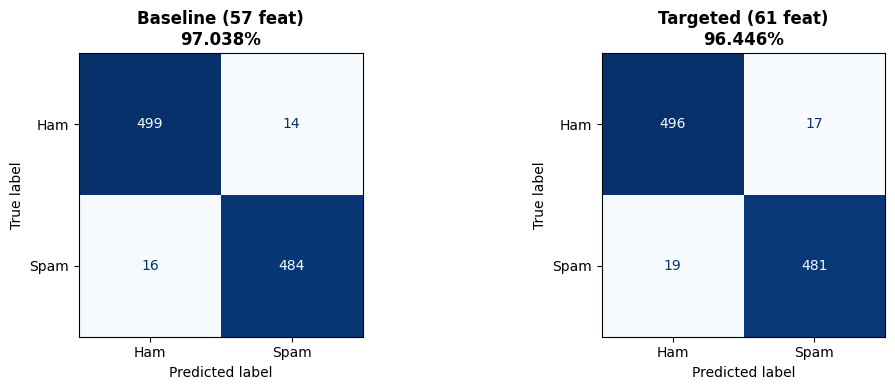

--- Baseline (57 feat) ---
              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       513
        Spam       0.97      0.97      0.97       500

    accuracy                           0.97      1013
   macro avg       0.97      0.97      0.97      1013
weighted avg       0.97      0.97      0.97      1013

--- Targeted (61 feat) ---
              precision    recall  f1-score   support

         Ham       0.96      0.97      0.96       513
        Spam       0.97      0.96      0.96       500

    accuracy                           0.96      1013
   macro avg       0.96      0.96      0.96      1013
weighted avg       0.96      0.96      0.96      1013



In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, (m, sc, X_tr, X_te, y_tr, y_te, pred, proba, acc)) in zip(axes, models.items()):
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n{acc:.3f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('improved_cm_targeted.png', dpi=150, bbox_inches='tight')
plt.show()

for name, (m, sc, X_tr, X_te, y_tr, y_te, pred, proba, acc) in models.items():
    print(f'--- {name} ---')
    print(classification_report(y_te, pred, target_names=['Ham', 'Spam']))

## 5. New Feature Importances

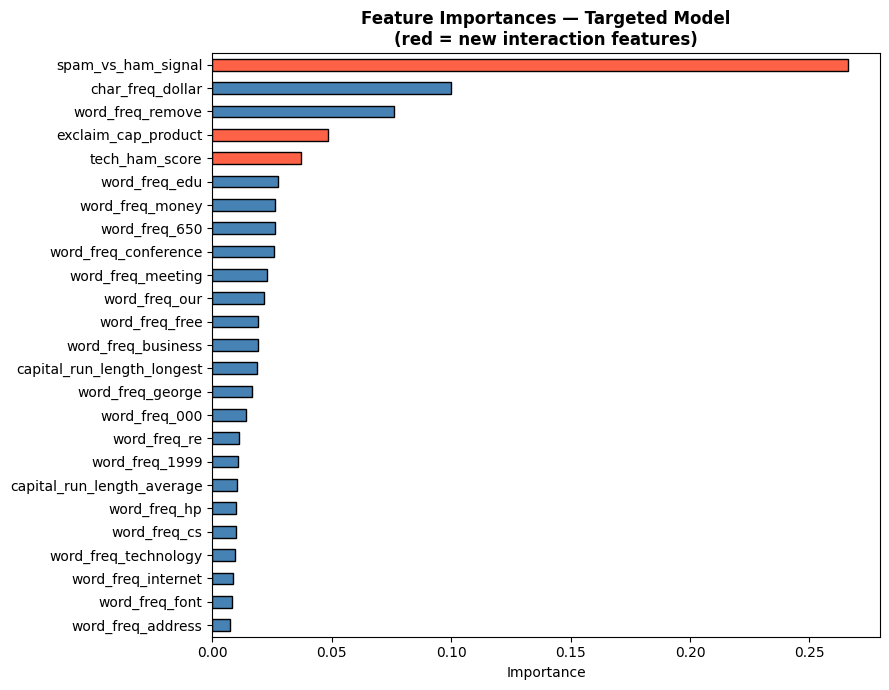

New feature importances:
  stealth_spam_score            : importance=0.0040  rank=#48 / 61
  tech_ham_score                : importance=0.0370  rank=#5 / 61
  spam_vs_ham_signal            : importance=0.2662  rank=#1 / 61
  exclaim_cap_product           : importance=0.0485  rank=#4 / 61


In [22]:
m_t, sc_t, X_tr_t, X_te_t, y_tr_t, y_te_t, pred_t, proba_t, acc_t = models['Targeted (61 feat)']
importances = pd.Series(m_t.feature_importances_, index=X_targeted.columns)
top25  = importances.nlargest(25)
colors = ['tomato' if f in new_features else 'steelblue' for f in top25.index]

fig, ax = plt.subplots(figsize=(9, 7))
top25.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='black')
ax.set_title('Feature Importances — Targeted Model\n(red = new interaction features)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('improved_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('New feature importances:')
all_ranked = importances.rank(ascending=False).astype(int)
for f in new_features:
    print(f'  {f:30s}: importance={importances[f]:.4f}  rank=#{all_ranked[f]} / {len(importances)}')

## 6. Summary

In [23]:
base = summary['Baseline (57 feat)']
targ = summary['Targeted (61 feat)']

print('=' * 70)
print('IMPROVEMENT SUMMARY')
print('=' * 70)
print(f'{"":30s} {"Baseline":>10} {"Targeted":>10} {"Change":>10}')
print('-' * 70)
print(f'{"Features":30s} {base["Features"]:>10} {targ["Features"]:>10} {targ["Features"]-base["Features"]:>+10}')
print(f'{"Train Accuracy":30s} {base["Train Acc"]:>9.3f}% {targ["Train Acc"]:>9.3f}% {targ["Train Acc"]-base["Train Acc"]:>+9.3f}%')
print(f'{"Test  Accuracy":30s} {base["Test Acc"]:>9.3f}% {targ["Test Acc"]:>9.3f}% {targ["Test Acc"]-base["Test Acc"]:>+9.3f}%')
print(f'{"False Positives (Ham→Spam)":30s} {base["FP"]:>10} {targ["FP"]:>10} {targ["FP"]-base["FP"]:>+10}')
print(f'{"False Negatives (Spam→Ham)":30s} {base["FN"]:>10} {targ["FN"]:>10} {targ["FN"]-base["FN"]:>+10}')
print(f'{"Total errors":30s} {base["Errors"]:>10} {targ["Errors"]:>10} {targ["Errors"]-base["Errors"]:>+10}')
print(f'{"Train-Test Gap":30s} {base["Gap"]:>9.3f}% {targ["Gap"]:>9.3f}% {targ["Gap"]-base["Gap"]:>+9.3f}%')
print('=' * 70)
print()
print('Targeted features (all derived from error analysis findings):')
desc = {
    'stealth_spam_score' : 'financial_words / (capital_total+1)  → catches low-cap spam (FN fix)',
    'tech_ham_score'     : 'hp_george × (capital_total+1)        → protects tech ham (FP fix)',
    'spam_vs_ham_signal' : 'stealth_spam - hp_george/(cap+1)     → combined discriminator',
    'exclaim_cap_product': 'char_freq_exclaim × capital_avg      → agitated spam pattern',
}
for f, d in desc.items():
    print(f'  {f:25s}: {d}')
print('=' * 70)

IMPROVEMENT SUMMARY
                                 Baseline   Targeted     Change
----------------------------------------------------------------------
Features                               57         61         +4
Train Accuracy                    99.827%    99.852%    +0.025%
Test  Accuracy                    97.038%    96.446%    -0.592%
False Positives (Ham→Spam)             14         17         +3
False Negatives (Spam→Ham)             16         19         +3
Total errors                           30         36         +6
Train-Test Gap                     2.789%     3.406%    +0.617%

Targeted features (all derived from error analysis findings):
  stealth_spam_score       : financial_words / (capital_total+1)  → catches low-cap spam (FN fix)
  tech_ham_score           : hp_george × (capital_total+1)        → protects tech ham (FP fix)
  spam_vs_ham_signal       : stealth_spam - hp_george/(cap+1)     → combined discriminator
  exclaim_cap_product      : char_freq_exclaim × c

# TODO: Delete this cell